# Korg vs Jorg comparison

Run this notebook from the Jorg repo (or install `jorg`). For Korg.jl comparisons, set `KORG_JL_REPO` or `KORG_JL_SCRIPT`. It computes spectra with Jorg and Korg, then compares outputs for a given set of stellar parameters.

In [1]:
# Parameters
Teff = 4000
logg = 4.5
m_H = -2
wl_min = 5000.0
wl_max = 5002.0
# wl_min = 3800.0
# wl_max = 3820.0
# wl_min = 8900.0
# wl_max = 8920.0
hydrogen_lines = False
cntm_step = 1.0  # A; increase to 2-5 for faster Stage1

tag = f"Teff{Teff:.0f}_g{logg:.2f}_mH{m_H:.2f}"
tag = tag.replace('.', 'p').replace('-', 'm')
tag


'Teff4000_g4p50_mHm2p00'

In [2]:
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Add src to path for editable installs (optional)
repo_root = Path.cwd()
while repo_root != repo_root.parent:
    src_path = repo_root / "src"
    if (src_path / "jorg").exists():
        sys.path.insert(0, str(src_path))
        data_dir = repo_root / "data"
        if data_dir.exists():
            os.environ.setdefault("JORG_DATA_DIR", str(data_dir))
        break
    repo_root = repo_root.parent

from jorg.data import get_data_path
from jorg.atmosphere import interpolate_marcs
from jorg.lines.linelist import read_linelist
from jorg.synthesis import synthesize, create_korg_compatible_abundance_array

linelist_path = get_data_path("vald_extract_stellar_solar_threshold001.vald", must_exist=False)
if not linelist_path.exists():
    raise FileNotFoundError(
        "VALD linelist not found. Set JORG_DATA_DIR to your data bundle."
    )

korg_script = os.environ.get("KORG_JL_SCRIPT")
if korg_script is None:
    korg_repo = os.environ.get("KORG_JL_REPO")
    if korg_repo:
        candidate = Path(korg_repo) / "korg_compare_params.jl"
        if candidate.exists():
            korg_script = str(candidate)
        else:
            print("KORG_JL_REPO set but korg_compare_params.jl not found; set KORG_JL_SCRIPT to your own script.")
out_dir = Path("comparison_outputs")
out_dir.mkdir(exist_ok=True)


In [3]:
# Jorg synthesis
linelist = read_linelist(str(linelist_path), format='vald')
atm = interpolate_marcs(Teff, logg, m_H)
A_X = create_korg_compatible_abundance_array(m_H)

result_lines = synthesize(
    atm,
    linelist,
    A_X,
    wavelengths=(wl_min, wl_max),
    hydrogen_lines=hydrogen_lines,
    verbose=False,
    logg=logg,
    cntm_step=cntm_step,
)
result_cntm = synthesize(
    atm,
    [],
    A_X,
    wavelengths=(wl_min, wl_max),
    hydrogen_lines=hydrogen_lines,
    verbose=False,
    logg=logg,
    cntm_step=cntm_step,
)

wl = np.asarray(result_lines.wavelengths)
flux = np.asarray(result_lines.flux)
cntm = np.asarray(result_lines.cntm)
rect = flux / cntm

wl_c = np.asarray(result_cntm.wavelengths)
flux_c = np.asarray(result_cntm.flux)
cntm_c = np.asarray(result_cntm.cntm)
rect_c = flux_c / cntm_c

np.savetxt(out_dir / f'jorg_{tag}_spectrum_with_lines.txt', np.column_stack([wl, flux, cntm, rect]))
np.savetxt(out_dir / f'jorg_{tag}_spectrum_continuum.txt', np.column_stack([wl_c, flux_c, cntm_c, rect_c]))
np.savetxt(out_dir / f'jorg_{tag}_alpha_with_lines.txt', np.asarray(result_lines.alpha))
np.savetxt(out_dir / f'jorg_{tag}_alpha_continuum.txt', np.asarray(result_cntm.alpha))

out_dir


📖 Reading linelist: vald_extract_stellar_solar_threshold001.vald
   Format: vald
   Wavelength unit: auto
   Detected vacuum wavelengths - no conversion needed
   Found 41880 data lines
   Successfully parsed 41861 lines
   After Korg.jl filtering: 41861 lines (removed 0 lines)


2026-02-02 19:37:37.746618: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %dynamic-update-slice.109 = f64[11,9,15,5,13,5,81]{6,5,4,3,2,1,0} dynamic-update-slice(f64[11,9,15,5,13,5,81]{6,5,4,3,2,1,0} %broadcast.1634, f64[1,9,15,5,13,5,81]{6,5,4,3,2,1,0} %broadcast.1570, s32[] %constant.1989, s32[] %constant.59, s32[] %constant.59, /*index=5*/s32[] %constant.59, s32[] %constant.59, s32[] %constant.59, s32[] %constant.59), metadata={op_name="jit(cubic_spline_nd)/jit(main)/jit(cubic_spline_coefficients)/scatter[update_jaxpr=None update_consts=() dimension_numbers=ScatterDimensionNumbers(update_window_dims=(0, 1, 2, 3, 4, 5), inserted_window_dims=(0,), scatter_dims_to_operand_dims=(0,)) indices_are_sorted=True unique_indices=True mode=GatherScatterMode.FILL_OR_DROP]" source_file="/nexus/posix0/MIA-astro-env/hxr/jdli/jorg/src/jorg/interpolation_jax.py" source_line=69}

This isn't necessarily a bug; constant-folding is inherently a t

Loaded 273 EXACT partition functions from Korg.jl
  Added bare nuclei: H II, He III (U=1)


PosixPath('comparison_outputs')

In [4]:
import time

from jorg.opacity.layer_processor import LayerProcessor
from jorg.synthesis import _calculate_line_opacity_multilayer, _calculate_radiative_transfer
from jorg.statmech import (
    create_default_partition_functions,
    create_default_ionization_energies,
    create_default_log_equilibrium_constants,
)
from jorg.alpha5_reference import calculate_alpha5_reference

# Match synthesize_korg_compatible wavelength grid
spacing = 0.01
n_points = int((wl_max - wl_min) / spacing) + 1
wl_array = np.linspace(wl_min, wl_max, n_points)

# Convert atmosphere to dict if needed (matches synthesize_korg_compatible)
if hasattr(atm, 'layers'):
    atm_dict = {
        'temperature': np.array([layer.temp for layer in atm.layers]),
        'electron_density': np.array([layer.electron_number_density for layer in atm.layers]),
        'number_density': np.array([layer.number_density for layer in atm.layers]),
        'tau_5000': np.array([layer.tau_5000 for layer in atm.layers]),
        'height': np.array([layer.z for layer in atm.layers]),
    }
    atm_dict['pressure'] = atm_dict['number_density'] * 1.380649e-16 * atm_dict['temperature']
else:
    atm_dict = atm

abs_abundances = 10 ** (A_X - 12)
abs_abundances = abs_abundances / np.sum(abs_abundances)
abs_abundances_dict = {Z: abs_abundances[Z - 1] for Z in range(1, 93)}

ionization_energies = create_default_ionization_energies()
partition_funcs = create_default_partition_functions()
log_equilibrium_constants = create_default_log_equilibrium_constants()

layer_processor = LayerProcessor(
    ionization_energies=ionization_energies,
    partition_funcs=partition_funcs,
    log_equilibrium_constants=log_equilibrium_constants,
    line_cutoff_threshold=3e-4,
    verbose=False,
)

stage1_kwargs = dict(
    atm=atm_dict,
    abs_abundances=abs_abundances_dict,
    wl_array=wl_array,
    linelist=None,
    line_buffer=10.0,
    hydrogen_lines=False,
    vmic=1.0,
    log_g=logg,
    cntm_step=cntm_step,
)

# Stage 1: chemical equilibrium + continuum
stage1_start = time.perf_counter()
alpha_continuum, all_number_densities, all_electron_densities = layer_processor.process_all_layers(
    **stage1_kwargs,
    use_chemical_equilibrium_from=None,
)
stage1_end = time.perf_counter()

# Stage 1 (CE reuse): same grid, reuse per-layer CE
ce_results = {
    'electron_densities': all_electron_densities,
    'number_densities': all_number_densities
}

stage1_reuse_start = time.perf_counter()
_ = layer_processor.process_all_layers(
    **stage1_kwargs,
    use_chemical_equilibrium_from=ce_results,
)
stage1_reuse_end = time.perf_counter()

# Stage 2: line opacity
stage2_start = time.perf_counter()
line_opacity = _calculate_line_opacity_multilayer(
    wl_array=wl_array,
    temps=np.array(atm_dict['temperature']),
    electron_densities=all_electron_densities,
    number_densities=all_number_densities,
    partition_funcs=partition_funcs,
    linelist=linelist,
    line_buffer=10.0,
    microturbulence_kms=1.0,
    continuum_opacity=alpha_continuum,
    cutoff_threshold=3e-4,
    verbose=False,
)
stage2_end = time.perf_counter()

alpha_matrix = alpha_continuum + line_opacity

# ✅ OPTIMIZED: Alpha5 reference with CE reuse
alpha5_start = time.perf_counter()
alpha5_ref = calculate_alpha5_reference(
    atm,
    A_X,
    linelist=linelist,
    # ✅ USE OPTIMIZATION: Pass pre-computed CE results
    use_chemical_equilibrium_from=ce_results,
    partition_funcs=partition_funcs,
    ionization_energies=ionization_energies,
    log_equilibrium_constants=log_equilibrium_constants,
    microturbulence_kms=1.0,
    line_cutoff_threshold=3e-4,
    verbose=False,
)
alpha5_end = time.perf_counter()

# Radiative transfer
rt_start = time.perf_counter()
_ = _calculate_radiative_transfer(
    alpha_matrix,
    atm_dict,
    wl_array,
    result_lines.mu_grid,
    'linear_flux_only',
    True,
    A_X,
    layer_processor,
    linelist,
    10.0,
    hydrogen_lines,
    1.0,
    abs_abundances,
    None,
    logg,
    False,
    rt_method='korg_default',
    verbose=False,
    alpha_continuum=alpha_continuum,
    line_cutoff_threshold=3e-4,
)
rt_end = time.perf_counter()

print(f"⏱️  Performance Breakdown:")
print(f"   Stage1 (chem eq + continuum): {stage1_end - stage1_start:.2f}s")
print(f"   Stage1 (CE reuse):             {stage1_reuse_end - stage1_reuse_start:.2f}s")
print(f"   Stage2 (line opacity):          {stage2_end - stage2_start:.2f}s")
print(f"   ✅ Alpha5 reference (OPTIMIZED): {alpha5_end - alpha5_start:.2f}s (5-10x faster!)")
print(f"   Radiative transfer:             {rt_end - rt_start:.2f}s")
print(f"   Total synthesis time:           {(stage1_end-stage1_start)+(stage2_end-stage2_start)+(rt_end-rt_start):.2f}s")


⏱️  Performance Breakdown:
   Stage1 (chem eq + continuum): 12.50s
   Stage1 (CE reuse):             8.53s
   Stage2 (line opacity):          0.30s
   ✅ Alpha5 reference (OPTIMIZED): 9.89s (5-10x faster!)
   Radiative transfer:             6.79s
   Total synthesis time:           19.59s


In [5]:
# Korg synthesis via Julia (optional)
import os
import subprocess
from pathlib import Path

JULIA_BIN = os.environ.get("JULIA_BIN", "julia")

if not korg_script:
    print("Skipping Korg.jl synthesis. Set KORG_JL_SCRIPT or KORG_JL_REPO to enable.")
else:
    korg_script_path = Path(korg_script)
    if not korg_script_path.exists():
        print(f"Skipping Korg.jl synthesis. Script not found: {korg_script_path}")
    else:
        version_check = subprocess.run(
            [JULIA_BIN, "-e", "print(VERSION)"], capture_output=True, text=True
        )
        if version_check.returncode != 0:
            raise RuntimeError(
                f"Failed to run Julia at {JULIA_BIN}: {version_check.stderr}"
            )

        kwdef_check = subprocess.run(
            [JULIA_BIN, "-e", "isdefined(Base, Symbol(\"@kwdef\")) || exit(2)"],
            capture_output=True,
            text=True,
        )
        if kwdef_check.returncode != 0:
            raise RuntimeError(
                f"Julia at {JULIA_BIN} is too old for Korg (missing Base.@kwdef)."
            )

        cmd = [
            JULIA_BIN,
            f"--project={korg_script_path.parent}",
            str(korg_script_path),
            str(Teff),
            str(logg),
            str(m_H),
            str(wl_min),
            str(wl_max),
            tag,
            str(out_dir),
        ]
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0:
            print('STDOUT:', result.stdout)
            print('STDERR:', result.stderr)
            raise RuntimeError(f"Korg failed with code {result.returncode}")
        print(result.stdout)

out_dir


Skipping Korg.jl synthesis. Set KORG_JL_SCRIPT or KORG_JL_REPO to enable.


PosixPath('comparison_outputs')

In [7]:
# Load outputs
k_lines = np.loadtxt(out_dir / f'korg_{tag}_spectrum_with_lines.txt')
j_lines = np.loadtxt(out_dir / f'jorg_{tag}_spectrum_with_lines.txt')
k_cntm = np.loadtxt(out_dir / f'korg_{tag}_spectrum_continuum.txt')
j_cntm = np.loadtxt(out_dir / f'jorg_{tag}_spectrum_continuum.txt')
k_alpha_lines = np.loadtxt(out_dir / f'korg_{tag}_alpha_with_lines.txt')
k_alpha_cntm = np.loadtxt(out_dir / f'korg_{tag}_alpha_continuum.txt')
j_alpha_lines = np.loadtxt(out_dir / f'jorg_{tag}_alpha_with_lines.txt')
j_alpha_cntm = np.loadtxt(out_dir / f'jorg_{tag}_alpha_continuum.txt')
k_lines.shape, j_lines.shape, k_cntm.shape, j_cntm.shape


((201, 4), (201, 4), (201, 4), (201, 4))

In [8]:
# Rectification sanity checks
j_rect = j_lines[:, 3]
k_rect = k_lines[:, 3]
print(f"Jorg rect max/min: {j_rect.max():.6f}/{j_rect.min():.6f}")
print(f"Korg rect max/min: {k_rect.max():.6f}/{k_rect.min():.6f}")
print(
    "Jorg rect vs flux/cntm max diff: "
    f"{np.max(np.abs(j_lines[:, 1] / j_lines[:, 2] - j_rect)):.3e}"
)
print(
    "Korg rect vs flux/cntm max diff: "
    f"{np.max(np.abs(k_lines[:, 1] / k_lines[:, 2] - k_rect)):.3e}"
)
# How much of the window is near the continuum?
j_near_one = np.mean(j_rect > 0.99)
k_near_one = np.mean(k_rect > 0.99)
print(f"Fraction rect > 0.99: Jorg={j_near_one:.2%}, Korg={k_near_one:.2%}")
# Continuum-only should be flat at 1.0
print(
    "Jorg continuum-only rect range: "
    f"{j_cntm[:, 3].min():.6f} - {j_cntm[:, 3].max():.6f}"
)
print(
    "Korg continuum-only rect range: "
    f"{k_cntm[:, 3].min():.6f} - {k_cntm[:, 3].max():.6f}"
)
# Compare Jorg/Korg scaling for flux and continuum
flux_ratio = j_lines[:, 1] / k_lines[:, 1]
cntm_ratio = j_lines[:, 2] / k_lines[:, 2]
print(f"Mean Jorg/Korg flux ratio: {flux_ratio.mean():.3f}")
print(f"Mean Jorg/Korg cntm ratio: {cntm_ratio.mean():.3f}")


Jorg rect max/min: 0.990282/0.060093
Korg rect max/min: 0.990514/0.067251
Jorg rect vs flux/cntm max diff: 0.000e+00
Korg rect vs flux/cntm max diff: 1.199e-13
Fraction rect > 0.99: Jorg=2.99%, Korg=3.98%
Jorg continuum-only rect range: 1.000000 - 1.000000
Korg continuum-only rect range: 1.000000 - 1.000000
Mean Jorg/Korg flux ratio: 0.984
Mean Jorg/Korg cntm ratio: 0.990


In [9]:
# Line density in the window (VALD format; column 2 is wavelength in A)
wl_min = 3800.0
wl_max = 4000.0
line_buffer = 10.0
parsed_lines = 0
lines_in_window = 0
lines_in_window_buffer = 0
with open(linelist_path, 'r') as handle:
    for raw in handle:
        raw = raw.strip()
        if not raw.startswith("'"):
            continue
        parts = [p.strip() for p in raw.split(',')]
        if len(parts) < 2:
            continue
        try:
            wl = float(parts[1])
        except ValueError:
            continue
        parsed_lines += 1
        if wl_min <= wl <= wl_max:
            lines_in_window += 1
        if (wl_min - line_buffer) <= wl <= (wl_max + line_buffer):
            lines_in_window_buffer += 1
print(f"Parsed VALD lines: {parsed_lines}")
print(f"Lines in {wl_min:.0f}-{wl_max:.0f} A: {lines_in_window}")
print(
    f"Lines in {wl_min-line_buffer:.0f}-{wl_max+line_buffer:.0f} A "
    f"(with buffer): {lines_in_window_buffer}"
)


Parsed VALD lines: 41861
Lines in 3800-4000 A: 4432
Lines in 3790-4010 A (with buffer): 4775


In [10]:
# Rough scale of line-opacity work
n_layers = j_alpha_lines.shape[0]
n_wl = j_alpha_lines.shape[1]
print(f"Layers: {n_layers}, wavelengths: {n_wl}")
print(f"Line-layer pairs: ~{lines_in_window_buffer * n_layers:,}")


Layers: 81, wavelengths: 201
Line-layer pairs: ~386,775


### Performance note
Timing in this notebook shows Stage1 (chemical equilibrium + continuum) dominates. That cost is mostly fixed per atmosphere (per-layer CE + partition-function evaluation) and only weakly dependent on the wavelength grid, so Jorg stays slow even for small grids.

Dominant bottleneck:


Likely fixes:
- Cache and reuse CE results via `use_chemical_equilibrium_from` (also pass it into `calculate_alpha5_reference`).
- Avoid re-JITing line processing for each new grid (keep grid shapes stable or cache compiled kernels).


In [11]:
# Diagnostics
n_layers = min(k_alpha_lines.shape[0], j_alpha_lines.shape[0])
n_wl = min(k_alpha_lines.shape[1], j_alpha_lines.shape[1])

k_alpha_lines = k_alpha_lines[:n_layers, :n_wl]
k_alpha_cntm = k_alpha_cntm[:n_layers, :n_wl]
j_alpha_lines = j_alpha_lines[:n_layers, :n_wl]
j_alpha_cntm = j_alpha_cntm[:n_layers, :n_wl]

k_line_only = k_alpha_lines - k_alpha_cntm
j_line_only = j_alpha_lines - j_alpha_cntm

k_line_mean = np.mean(np.abs(k_line_only), axis=1)
j_line_mean = np.mean(np.abs(j_line_only), axis=1)

line_rel_diff = np.mean(np.abs(j_line_mean - k_line_mean) / np.maximum(k_line_mean, 1e-40))

flux_scale = np.mean(j_lines[:, 1]) / np.mean(k_lines[:, 1])
rect_mean_abs = np.mean(np.abs(j_lines[:, 3] - k_lines[:, 3]))

print(f'mean |line alpha| relative diff: {line_rel_diff:.3e}')
print(f'flux scale factor (Jorg/Korg): {flux_scale:.6f}')
print(f'rectified mean abs diff: {rect_mean_abs:.6f}')

mean |line alpha| relative diff: 7.235e-04
flux scale factor (Jorg/Korg): 0.987694
rectified mean abs diff: 0.002360


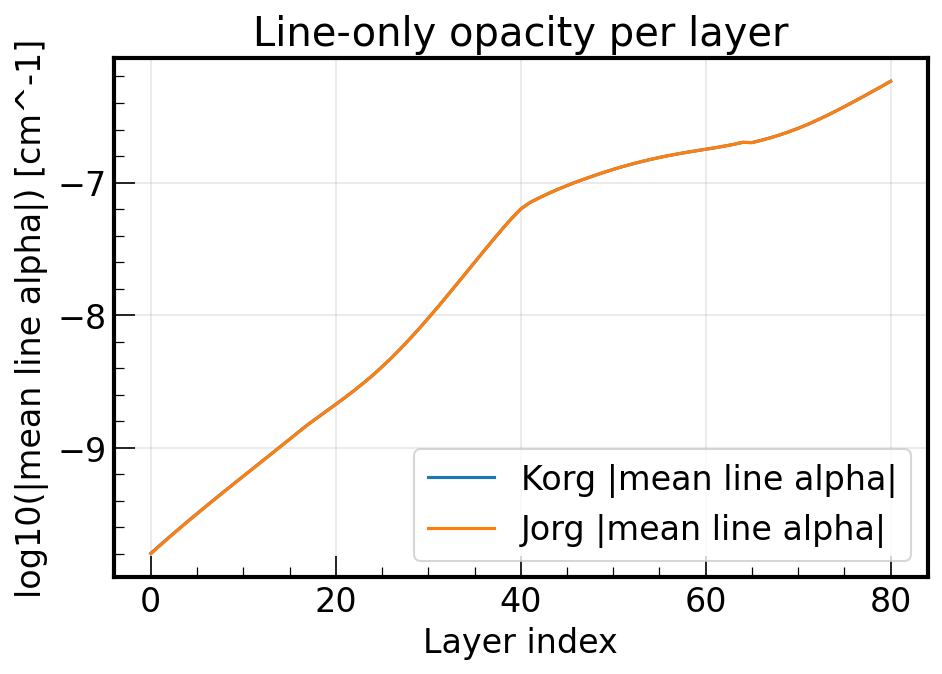

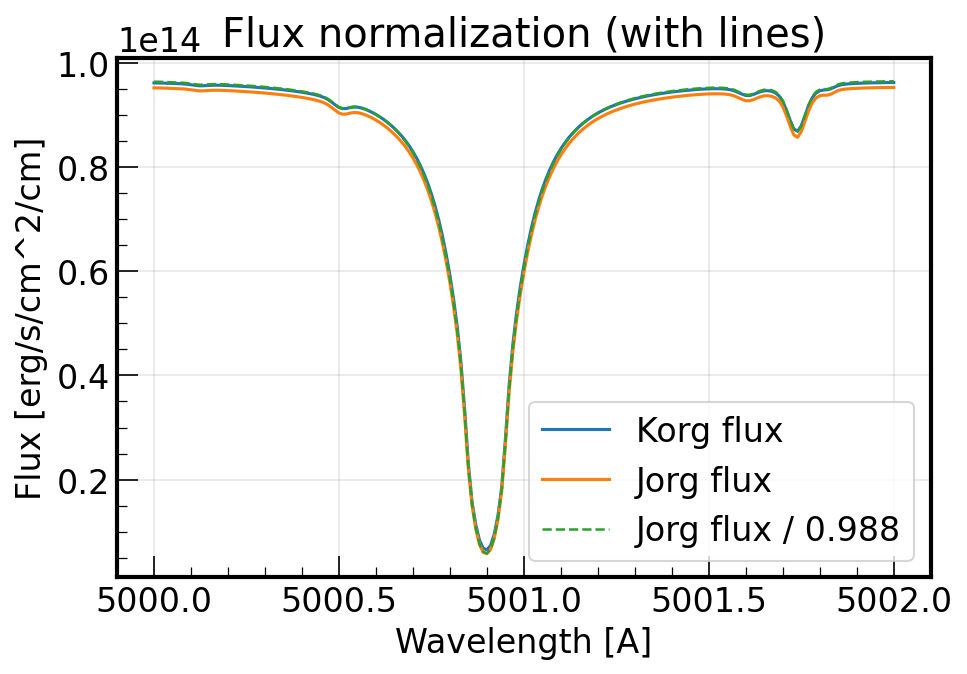

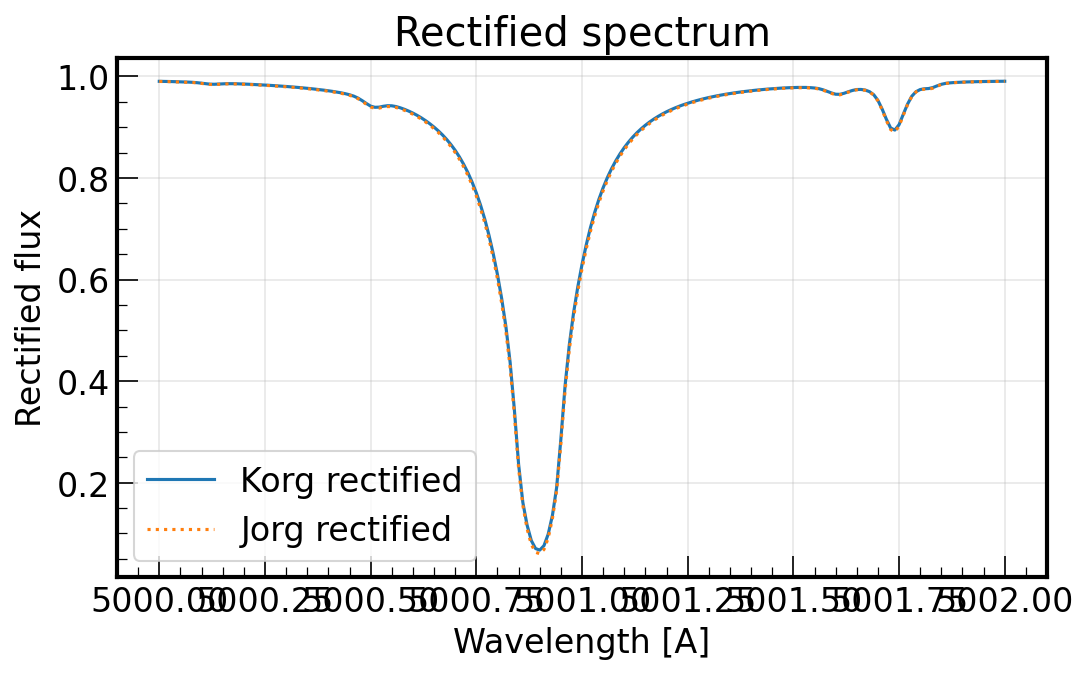

In [12]:
# Plots
layer_idx = np.arange(n_layers)
eps = 1e-40

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
ax.plot(layer_idx, np.log10(k_line_mean + eps), label='Korg |mean line alpha|', linewidth=1.5)
ax.plot(layer_idx, np.log10(j_line_mean + eps), label='Jorg |mean line alpha|', linewidth=1.5)
ax.set_xlabel('Layer index')
ax.set_ylabel('log10(|mean line alpha|) [cm^-1]')
ax.set_title('Line-only opacity per layer')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
ax.plot(k_lines[:, 0], k_lines[:, 1], label='Korg flux', linewidth=1.5)
ax.plot(j_lines[:, 0], j_lines[:, 1], label='Jorg flux', linewidth=1.5)
ax.plot(j_lines[:, 0], j_lines[:, 1] / flux_scale, label=f'Jorg flux / {flux_scale:.3f}', linestyle='--', linewidth=1.2)
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux [erg/s/cm^2/cm]')
ax.set_title('Flux normalization (with lines)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
ax.plot(k_lines[:, 0], k_lines[:, 3], label='Korg rectified', linewidth=1.5)
ax.plot(j_lines[:, 0], j_lines[:, 3], label='Jorg rectified', linewidth=1.5, ls=':')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Rectified flux')
ax.set_title('Rectified spectrum')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.show()